In [1]:
from helper import *

I moved classes and functions from the previous notebook to the `helper.py` not to rewrite the same code

In [2]:
HR_train_paths = sorted(glob.glob("../data/DIV2K_train_HR/*.png"))
X2_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X2/*.png"))
X4_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X4/*.png"))
X8_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X8/*.png"))
X16_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X16/*.png"))
X32_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X32/*.png"))
X64_train_paths = sorted(glob.glob("../data/DIV2K_train_LR_bicubic/X64/*.png"))

HR_valid_paths = sorted(glob.glob("../data/DIV2K_valid_HR/*.png"))
X2_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X2/*.png"))
X4_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X4/*.png"))
X8_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X8/*.png"))
X16_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X16/*.png"))
X32_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X32/*.png"))
X64_valid_paths = sorted(glob.glob("../data/DIV2K_valid_LR_bicubic/X64/*.png"))

## X8 Scaling

The process of preparation for training is the same as in 4X notebook, but the starting point is the **4X model**, not the 2X model

In [3]:
checkpoint = torch.load('../model_checkpoints/SRResNet/X4.pth')
model = SRResNet(4).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

model.upscaling_head = model.upscaling_head[:-1]

head = nn.Sequential(
    nn.Conv2d(64, 256, 3, stride=1, padding='same'),
    nn.PixelShuffle(2),
    nn.PReLU(),
    nn.Conv2d(64, 3, 9, stride=1, padding='same')
)

model.upscaling_head = nn.Sequential(*model.upscaling_head, *head)

for param in model.expand.parameters():
    param.requires_grad = False

for param in model.residual_blocks.parameters():
    param.requires_grad = False

for param in model.upscaling_head[:-4].parameters():
    param.requires_grad = False

summary(model, col_names=['trainable'])

Layer (type:depth-idx)                   Trainable
SRResNet                                 Partial
├─Sequential: 1-1                        False
│    └─Conv2d: 2-1                       False
│    └─PReLU: 2-2                        False
├─Sequential: 1-2                        False
│    └─ResBlock: 2-3                     False
│    │    └─Sequential: 3-1              False
│    └─ResBlock: 2-4                     False
│    │    └─Sequential: 3-2              False
│    └─ResBlock: 2-5                     False
│    │    └─Sequential: 3-3              False
│    └─ResBlock: 2-6                     False
│    │    └─Sequential: 3-4              False
│    └─ResBlock: 2-7                     False
│    │    └─Sequential: 3-5              False
│    └─ResBlock: 2-8                     False
│    │    └─Sequential: 3-6              False
│    └─ResBlock: 2-9                     False
│    │    └─Sequential: 3-7              False
│    └─ResBlock: 2-10                    False
│    │ 

In [3]:
valid_ds = SRResNet_Dataset(HR_valid_paths, 8, ram_limit_gb=1)

Preloading images:   0%|          | 0/100 [00:00<?, ?it/s]

In [4]:
train_ds = SRResNet_Dataset(HR_train_paths, 8, ram_limit_gb=8)

Preloading images:   0%|          | 0/800 [00:00<?, ?it/s]

In [6]:
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=os.cpu_count()-1)
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=os.cpu_count()-1)

loss_fn = nn.L1Loss()
optimizer = Adam(model.upscaling_head[-4:].parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=200, gamma=0.5)
model = model.to(device) # put on device the new upscaling head

train(model, train_dl, valid_dl, optimizer, scheduler, loss_fn, 1000)

Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 1 | learning rate: 0.0001000 | [train] PSNR: 14.8213 | [train] SSIM: 0.4484 | [valid] PSNR: 18.6652 | [valid] SSIM: 0.5033 | [valid] LPIPS: 0.6532
Epoch: 2 | learning rate: 0.0001000 | [train] PSNR: 20.3713 | [train] SSIM: 0.5366 | [valid] PSNR: 21.0611 | [valid] SSIM: 0.5567 | [valid] LPIPS: 0.5708
Epoch: 3 | learning rate: 0.0001000 | [train] PSNR: 21.6698 | [train] SSIM: 0.5600 | [valid] PSNR: 22.0735 | [valid] SSIM: 0.5893 | [valid] LPIPS: 0.5485
Epoch: 4 | learning rate: 0.0001000 | [train] PSNR: 22.3185 | [train] SSIM: 0.5839 | [valid] PSNR: 22.6301 | [valid] SSIM: 0.5943 | [valid] LPIPS: 0.5410
Epoch: 5 | learning rate: 0.0001000 | [train] PSNR: 22.4606 | [train] SSIM: 0.5952 | [valid] PSNR: 22.4848 | [valid] SSIM: 0.5968 | [valid] LPIPS: 0.5437
Epoch: 6 | learning rate: 0.0001000 | [train] PSNR: 22.3463 | [train] SSIM: 0.5977 | [valid] PSNR: 22.3436 | [valid] SSIM: 0.6030 | [valid] LPIPS: 0.5337
Epoch: 7 | learning rate: 0.0001000 | [train] PSNR: 22.7364 | [train] SSIM: 

In [3]:
checkpoint = torch.load('../tmp_model_checkpoints/last.pth')
model = SRResNet(8).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [20]:
model.eval();

In [8]:
targets = [X8_valid_paths, X4_valid_paths, X2_valid_paths, HR_valid_paths]

metrics_x8 = pd.DataFrame(columns=["PSNR↑", "SSIM↑", "LPIPS↓"])
for target_ds in tqdm(targets, total=4):
    metrics_x8.loc[len(metrics_x8)] = calc_metrics(model, target_ds, 8)

metrics_x8.index = ["31px -> 248px", "63px -> 504px", "127px -> 1016px", "255px -> 2040px"]
metrics_x8

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,PSNR↑,SSIM↑,LPIPS↓
31px -> 248px,20.745085,0.507295,0.547369
63px -> 504px,22.012406,0.571407,0.504829
127px -> 1016px,23.662075,0.639788,0.458120
255px -> 2040px,25.283079,0.684975,0.447323


## Day 1

I split the training into 2 days, because it is too long

In [6]:
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=os.cpu_count()-1)
valid_dl = DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=os.cpu_count()-1)

loss_fn = nn.L1Loss()
optimizer = Adam(model.parameters(), lr=1e-5)
scheduler = StepLR(optimizer, step_size=1000, gamma=0.5)

train(model, train_dl, valid_dl, optimizer, scheduler, loss_fn, 2500)

Epochs:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch: 1 | learning rate: 0.0000100 | [train] PSNR: 23.1076 | [train] SSIM: 0.6528 | [valid] PSNR: 23.1383 | [valid] SSIM: 0.6611 | [valid] LPIPS: 0.4398
Epoch: 6 | learning rate: 0.0000100 | [train] PSNR: 23.1634 | [train] SSIM: 0.6567 | [valid] PSNR: 23.3214 | [valid] SSIM: 0.6653 | [valid] LPIPS: 0.4430
Epoch: 8 | learning rate: 0.0000100 | [train] PSNR: 23.1027 | [train] SSIM: 0.6526 | [valid] PSNR: 23.4305 | [valid] SSIM: 0.6743 | [valid] LPIPS: 0.4380
Epoch: 14 | learning rate: 0.0000100 | [train] PSNR: 23.0785 | [train] SSIM: 0.6437 | [valid] PSNR: 23.4596 | [valid] SSIM: 0.6659 | [valid] LPIPS: 0.4416
Epoch: 22 | learning rate: 0.0000100 | [train] PSNR: 23.0015 | [train] SSIM: 0.6440 | [valid] PSNR: 23.5504 | [valid] SSIM: 0.6650 | [valid] LPIPS: 0.4525
Epoch: 24 | learning rate: 0.0000100 | [train] PSNR: 22.9869 | [train] SSIM: 0.6458 | [valid] PSNR: 23.6050 | [valid] SSIM: 0.6770 | [valid] LPIPS: 0.4392
Epoch: 37 | learning rate: 0.0000100 | [train] PSNR: 23.0544 | [train] SS

In [3]:
checkpoint = torch.load('../model_checkpoints/SRResNet/X8.pth')
model = SRResNet(8).to(device)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [4]:
model.eval();

In [5]:
targets = [X8_valid_paths, X4_valid_paths, X2_valid_paths, HR_valid_paths]

metrics_x8 = pd.DataFrame(columns=["PSNR↑", "SSIM↑", "LPIPS↓"])
for target_ds in tqdm(targets, total=4):
    metrics_x8.loc[len(metrics_x8)] = calc_metrics(model, target_ds, 8)

metrics_x8.index = ["31px -> 248px", "63px -> 504px", "127px -> 1016px", "255px -> 2040px"]
metrics_x8

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,PSNR↑,SSIM↑,LPIPS↓
31px -> 248px,20.770887,0.511819,0.539054
63px -> 504px,22.038205,0.575173,0.495814
127px -> 1016px,23.698920,0.643392,0.450260
255px -> 2040px,25.312492,0.687486,0.441936


I doubt it will get much better, hence I end the training here

### Super-resolution showcase

31px -> 248px


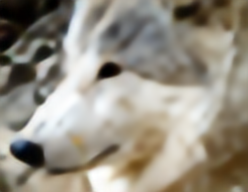

In [9]:
print("31px -> 248px")
inp = transform(Image.open(X64_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/8X/31px', exist_ok=True)
img.save('../image_results/8X/31px/SRResNet_31px.png')
img

63px -> 504px


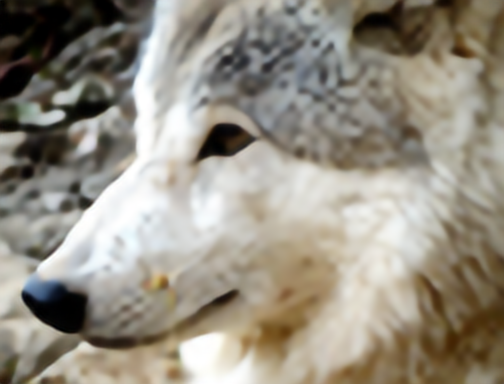

In [10]:
print("63px -> 504px")
inp = transform(Image.open(X32_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/8X/63px', exist_ok=True)
img.save('../image_results/8X/63px/SRResNet_63px.png')
img

127px -> 1016px


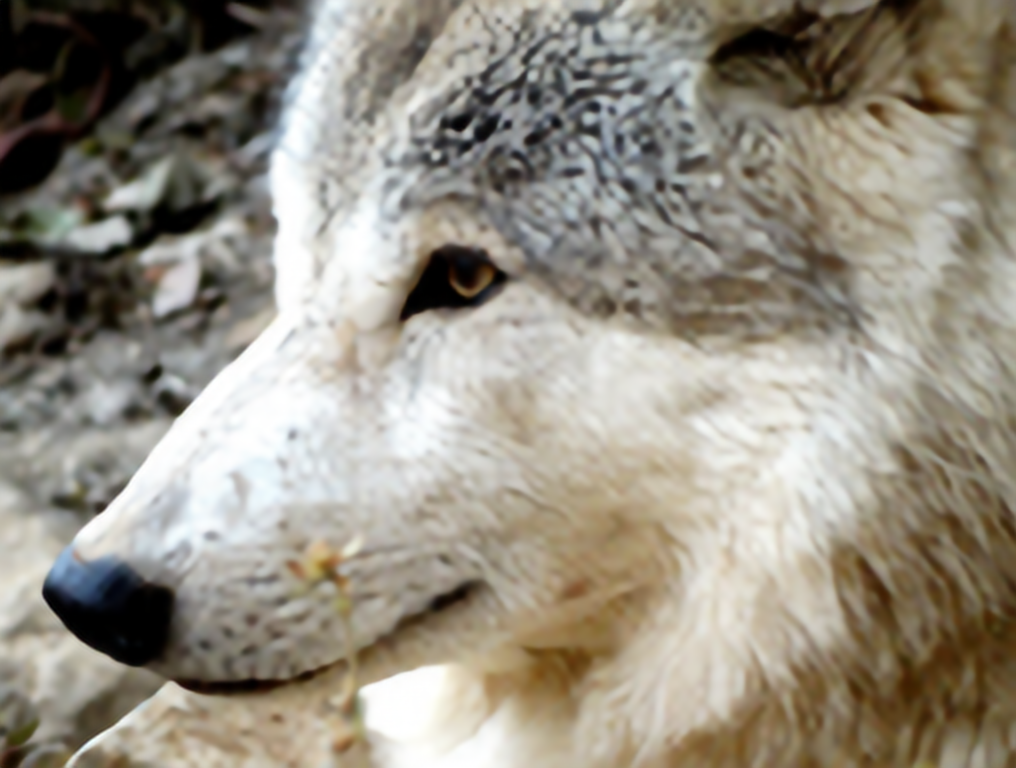

In [11]:
print("127px -> 1016px")
inp = transform(Image.open(X16_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/8X/127px', exist_ok=True)
img.save('../image_results/8X/127px/SRResNet_127px.png')
img

255px -> 2040px


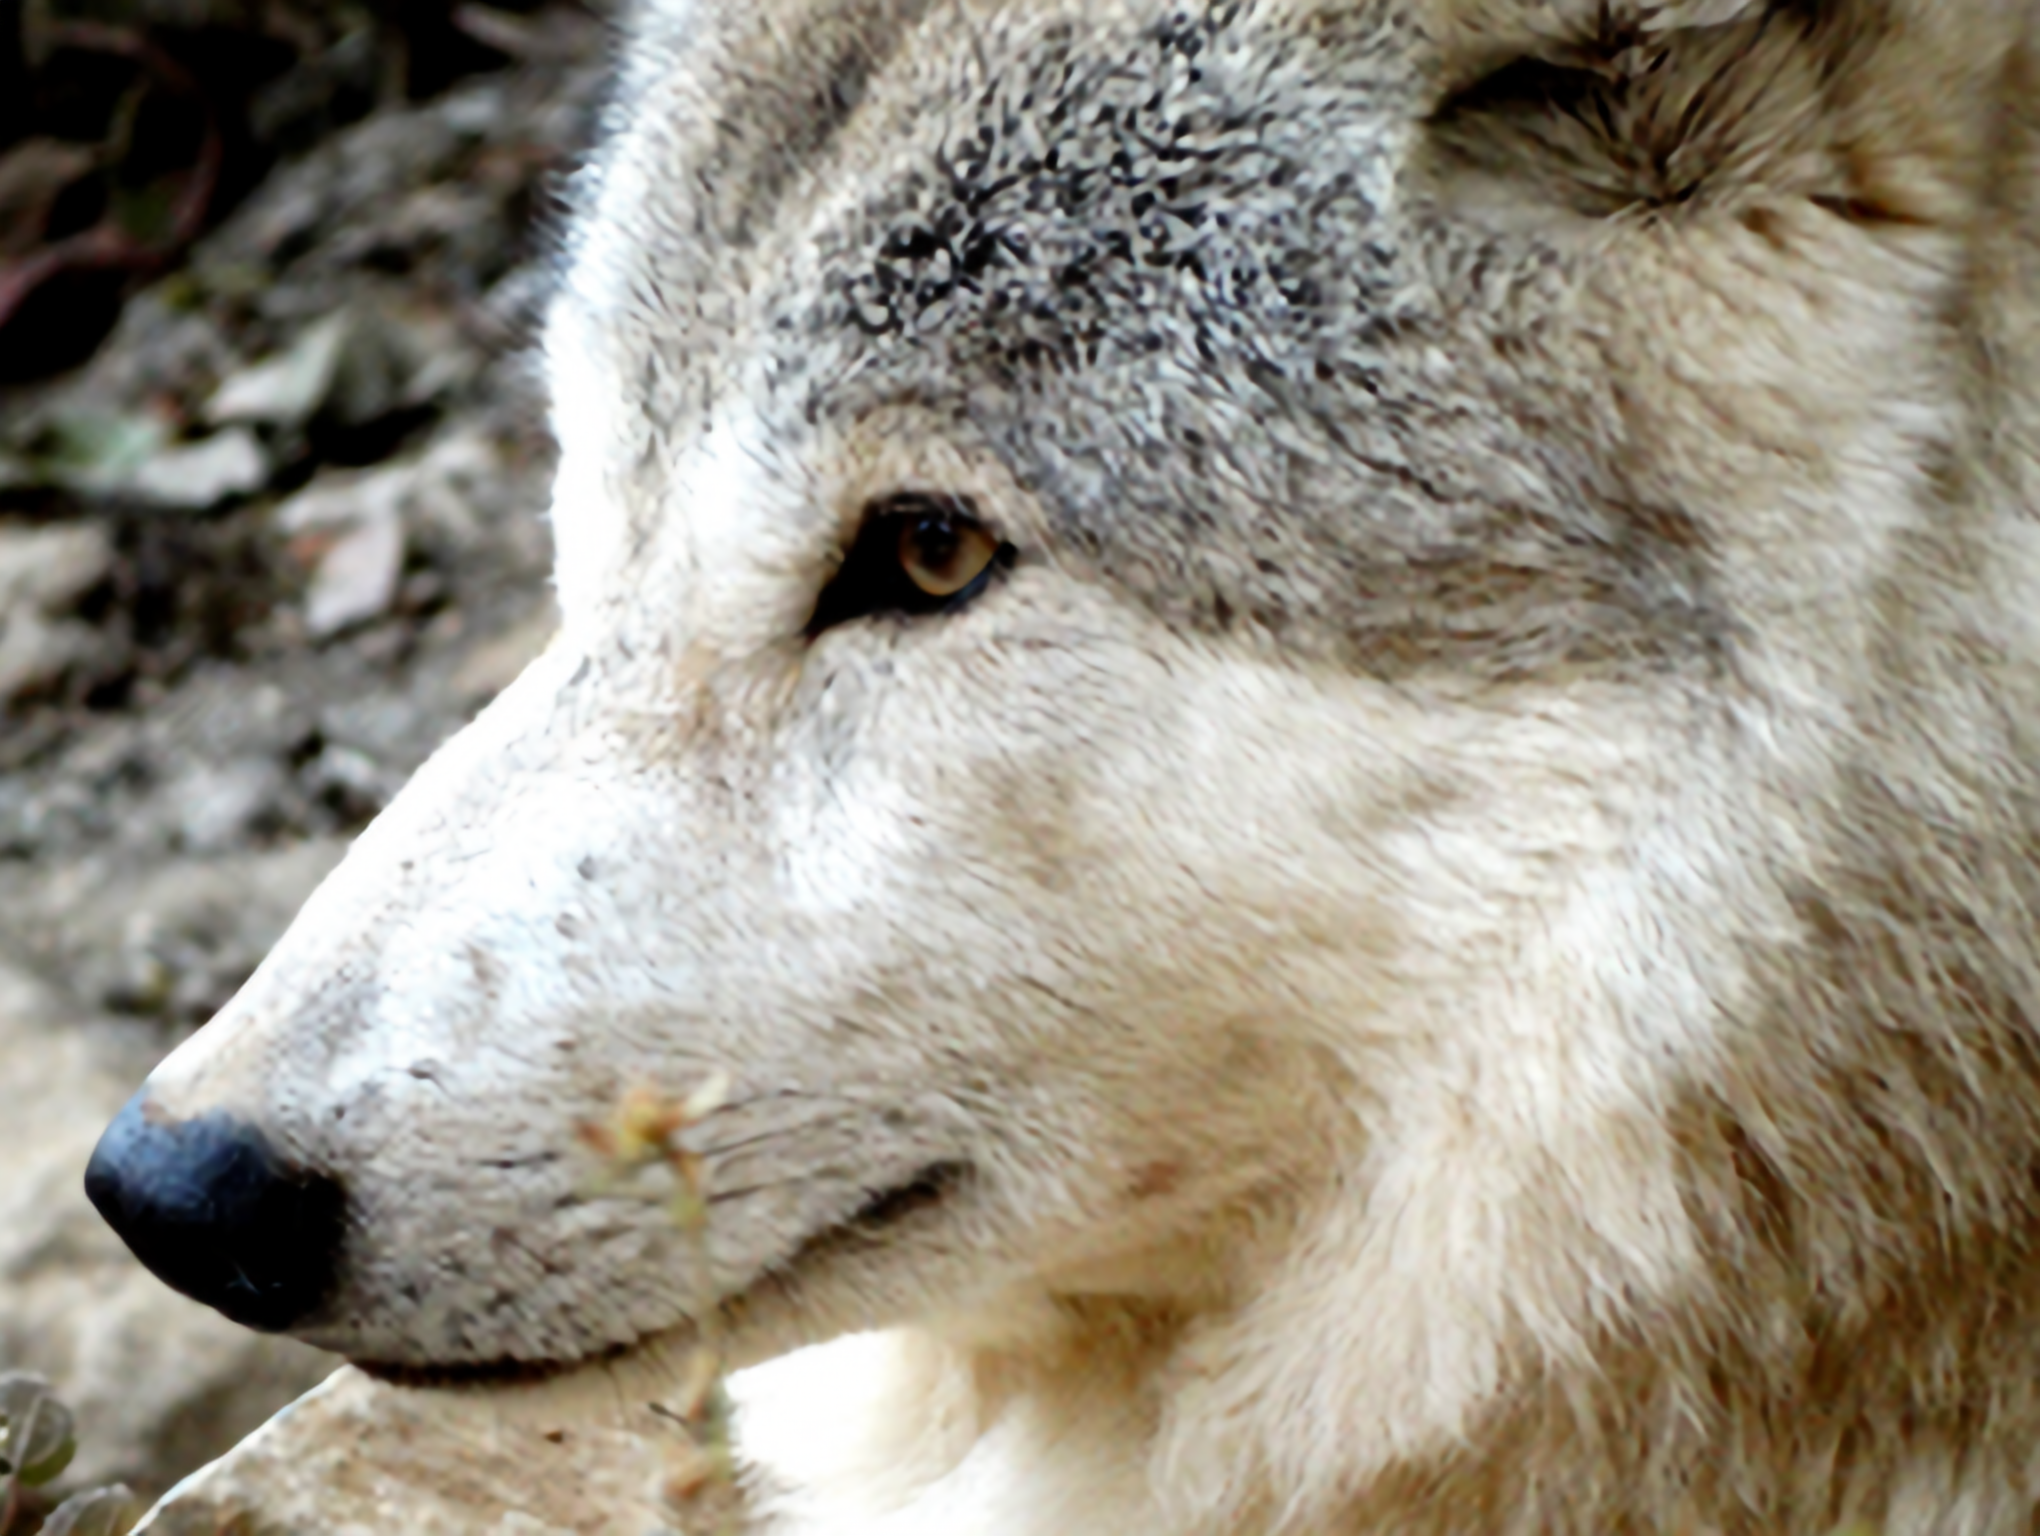

In [12]:
print("255px -> 2040px")
inp = transform(Image.open(X8_valid_paths[4])).to(device)
with torch.inference_mode():
    out = (((model(inp[None])+1.0)/2.0).clamp(0.0, 1.0) * 255.0).squeeze()

img = Image.fromarray(out.permute(1, 2, 0).to(torch.uint8).cpu().numpy())
os.makedirs('../image_results/8X/255px', exist_ok=True)
img.save('../image_results/8X/255px/SRResNet_255px.png')
img